# 🌊 Data Science Capstone Project: E-Commerce Customer Churn Prediction
**Course:** Data Science (ISB02303402)  
**Methodology:** CRISP-DM Framework  
**Group Name:** Cry Me a River  
**Team Members:** 
1. Daniel Roger Kennedy  
2. Lennard Lucius Huang  
3. Akhnan Iban Fahrezi  

---

## 📑 7-Step Machine Learning Pipeline Overview:
1. **Step 1: Workspace Setup & Data Ingestion**
2. **Step 2: Exploratory Data Analysis (EDA) & Data Quality Profiling**
3. **Step 3: Handling Missing Values (Behavioral Imputation)**
4. **Step 4: Categorical Feature Encoding (Matrix Transformation)**
5. **Step 5: Continuous Feature Scaling & Outlier Mitigation**
6. **Step 6: Stratified Partitioning & Addressing Class Imbalance (SMOTE)**
7. **Step 7: Model Training, Hyperparameter Tuning, & Recall-Optimized Evaluation**

---

## 🛠️ Step 1: Workspace Setup & Data Ingestion
At this initial stage, we import the fundamental libraries essential for numerical computation, matrix manipulation (`pandas` and `numpy`), and statistical data visualization (`matplotlib` and `seaborn`).

### **Why use Pandas & Numpy instead of Pure Python built-in functions?**
* **Pandas DataFrames** store data in highly optimized, columnar tabular formats backed by C arrays. Processing thousands of rows using pure Python nested lists or dictionaries forces sequential execution, causing severe CPU latency.
* **Numpy Arrays** utilize **Vectorization**. This ensures mathematical operations on whole data columns are run concurrently in parallel memory channels via SIMD (Single Instruction, Multiple Data) architectures, completely eliminating sluggish, native python `for` loops.

We will load the raw `EComm.csv` dataset and inspect its base structural dimensions.

In [1]:
# ==============================================================================
# STEP 1: WORKSPACE SETUP & INITIAL DATA INGESTION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Standardizing data visualization theme settings for consistent aesthetic reports
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.facecolor'] = '#f8f9fa'

# Extracting raw dataset into the active execution kernel environment
# Note: Ensure 'EComm.csv' is uploaded to your workspace directory
file_name = 'EComm.csv'
df = pd.read_csv(file_name)

# Printing basic structural metadata dimensions
print("=== WORKSPACE STORAGE ACQUISITION DETECTED ===")
print(f"Data Connection Status : [ACTIVE]")
print(f"Total Structural Rows  : {df.shape[0]:,}")
print(f"Total Structural Features: {df.shape[1]}")

# Verifying structural alignment via top records preview
df.head()

=== WORKSPACE STORAGE ACQUISITION DETECTED ===
Data Connection Status : [ACTIVE]
Total Structural Rows  : 5,630
Total Structural Features: 20


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 📊 Step 2: Exploratory Data Analysis (EDA) & Data Quality Profiling
Before performing model compilation, we must rigorously audit the data's structural integrity. Every column is assessed for its data type, count of unique values, and exact missing value distribution metrics.

### **Why must we run detailed Data Quality Profiling?**
* Machine learning frameworks (such as Random Forest or XGBoost) calculate math boundaries based on numeric vectors or split entropy. Raw string object datatypes passed into these equations cause system failures.
* Identifying **Missing Values** reveals whether data gaps are completely random or generated by user behavior anomalies (*Missing Not At Random*).

Additionally, we introduce statistical **Boxplots** to observe how outliers are distributed across critical variables (`CashbackAmount`, `WarehouseToHome`, and `DaySinceLastOrder`) when paired against our target label `Churn`.

=== COMPREHENSIVE DATA QUALITY REPORT ===


,Null Records Count,Missing Percentage (%),Zero Values Count,System Data Type,Unique Values Cardinality
Churn,0,0.0,4682,int64,2
Tenure,0,0.0,508,float64,36
PreferredLoginDevice,0,0.0,0,str,3
CityTier,0,0.0,0,int64,3
WarehouseToHome,0,0.0,0,float64,34
PreferredPaymentMode,0,0.0,0,str,7
Gender,0,0.0,0,str,2
HourSpendOnApp,0,0.0,3,float64,6
NumberOfDeviceRegistered,0,0.0,0,int64,6
PreferedOrderCat,0,0.0,0,str,6


Total Duplicate Rows Detected: 558

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Churn,5630.0,0.168384,0.374240,0.0,0.0,0.0,0.0,1.0
Tenure,5630.0,10.134103,8.357951,0.0,3.0,9.0,15.0,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5630.0,15.566785,8.345961,5.0,9.0,14.0,20.0,127.0
HourSpendOnApp,5630.0,2.934636,0.705528,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.0,3.0,4.0,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.0,3.0,6.0,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.0,0.0,1.0,1.0
OrderAmountHikeFromlastYear,5630.0,15.674600,3.591058,11.0,13.0,15.0,18.0,26.0



=== CHURN CLASS DISTRIBUTION ===
Class 0: 4682 rows (83.16%)
Class 1: 948 rows (16.84%)


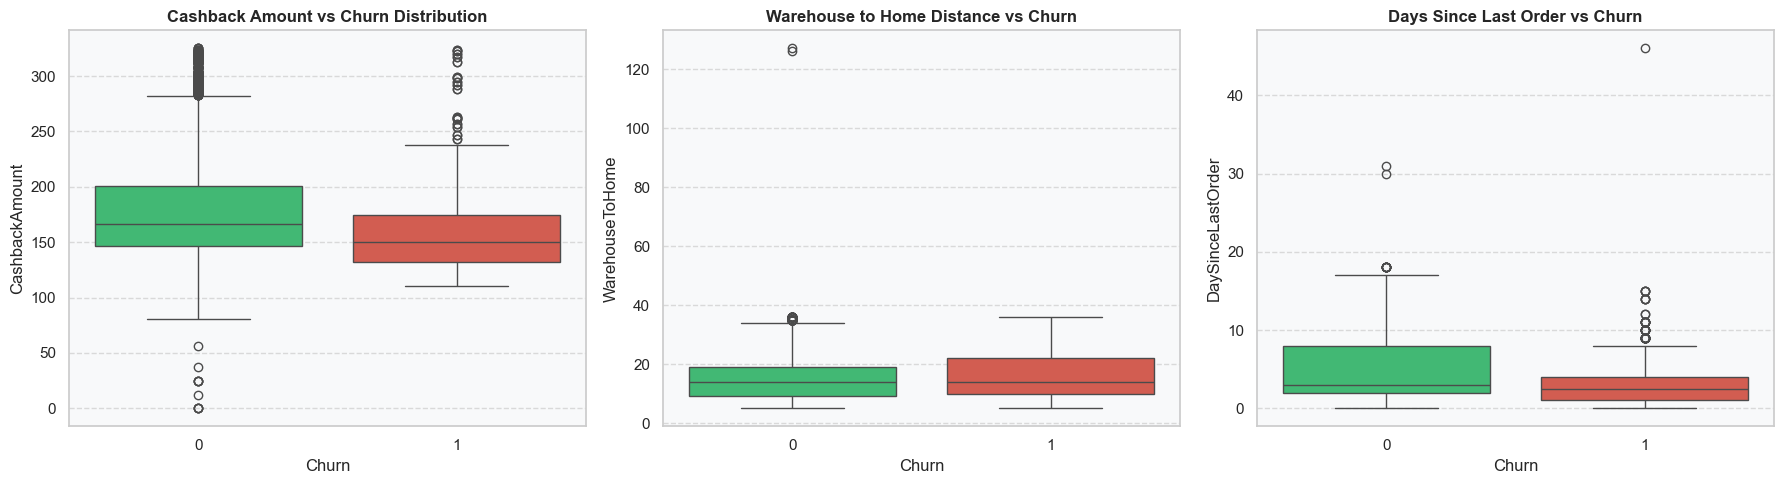

In [12]:
# ==============================================================================
# STEP 2: DATA QUALITY REPORT & DESCRIPTIVE STATISTICS (OPTIMIZED)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Enhanced Data Quality Report
# Menambahkan pengecekan duplikasi dan persentase zero values yang sering krusial di data bisnis
data_quality_report = pd.DataFrame({
    'Null Records Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100,
    'Zero Values Count': (df == 0).sum(),
    'System Data Type': df.dtypes,
    'Unique Values Cardinality': df.nunique()
}).sort_values(by='Null Records Count', ascending=False)

print("=== COMPREHENSIVE DATA QUALITY REPORT ===")
display(data_quality_report)
print(f"Total Duplicate Rows Detected: {df.duplicated().sum()}")

# 2. Inspecting detailed mathematical ranges of numerical attributes
print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe().T)

# 3. Class Imbalance Check (Sangat Krusial untuk Kasus Churn!)
print("\n=== CHURN CLASS DISTRIBUTION ===")
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
for idx in churn_counts.index:
    print(f"Class {idx}: {churn_counts[idx]} rows ({churn_pct[idx]:.2f}%)")

# 4. Outlier identification using grouped Boxplots mapped against Churn 
# Fix: Mengatasi FutureWarning dan menambahkan warna kontras yang jelas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features_to_plot = ['CashbackAmount', 'WarehouseToHome', 'DaySinceLastOrder']
titles = ['Cashback Amount vs Churn Distribution', 'Warehouse to Home Distance vs Churn', 'Days Since Last Order vs Churn']

for i, col in enumerate(features_to_plot):
    sns.boxplot(
        data=df, 
        x='Churn', 
        y=col, 
        ax=axes[i], 
        hue='Churn',          # Menghilangkan FutureWarning
        palette=['#2ecc71', '#e74c3c'], 
        legend=False          # Menyembunyikan legenda agar rapi
    )
    axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan grid agar pencilan mudah dibaca

plt.tight_layout()
plt.show()

## 🧼 Step 3: Handling Missing Values (Behavioral Imputation)
Our previous data quality report identified distinct missing data vectors within `DaySinceLastOrder`, `OrderAmountHikeFromlastYear`, `Tenure`, `OrderCount`, `CouponUsed`, `HourSpendOnApp`, and `WarehouseToHome` columns.

### **Why use Median values for data imputation instead of the Mean (Average)?**
* **The Failure of Mean Imputation:** The *Mean* metric is highly volatile and easily skewed by extreme outliers. Looking at our Step 2 boxplots, features like `WarehouseToHome` show extreme maximum values despite 75% of users living within a short distance. Imputing null slots with an average would pull values artificially upwards, introducing structural bias.
* **The Robustness of Median Imputation:** The *Median* represents the exact spatial center of sorted array points. It remains completely insulated from extreme trailing outliers because it measures sequence positioning rather than magnitude sums.

We also invoke a deliberate `.drop()` function to permanently delete the `CustomerID` variable.
* **The Reason:** `CustomerID` is a sequential, arbitrary metadata index assigned upon record generation. It holds no physical statistical correlation or predictive pattern towards customer loyalty. Retaining it adds dead dimensional noise, exposing our models to the *Curse of Dimensionality*.

In [13]:
# ==============================================================================
# STEP 3: FEATURE DROPPING & ROBUST MEDIAN IMPUTATION
# ==============================================================================

# 1. Eliminating operational non-predictive metadata tracking identifiers
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

# 2. Packaging structural columns containing missing elements
columns_to_impute = [
    'DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'Tenure', 
    'OrderCount', 'CouponUsed', 'HourSpendOnApp', 'WarehouseToHome'
]

# 3. Programmatically filling data spaces using individual localized column Medians
for col in columns_to_impute:
    if col in df.columns:
        median_marker = df[col].median()
        df[col] = df[col].fillna(median_marker) # Menggantikan inplace=True

# Confirming systemic cleanup completion
print(f"Total Residual Null Records remaining across Dataframe: {df.isnull().sum().sum()}")

Total Residual Null Records remaining across Dataframe: 0


## 🔣 Step 4: Categorical Feature Encoding (Matrix Transformation)
Raw qualitative textual elements like `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, and `MaritalStatus` cannot be directly processed by algebraic algorithms. They must be transformed into clean binary numeric representations (0 and 1).

### **Why choose One-Hot Encoding over Label Encoding?**
* **The Core Malfunction of Label Encoding:** Converting structural classifications like categorical location tiers into flat ordinal markers `[0, 1, 2]` causes models to evaluate them with a false sense of hierarchy ($2 > 0$).
* **The One-Hot Solution & Column Cleaning:** Executing `pd.get_dummies()` splits multi-class objects into individual columns for each string state. To prevent formatting issues in downstream boosting algorithms, we systematically replace spaces and special characters with underscores.

In [14]:
# ==============================================================================
# STEP 4: CATEGORICAL FEATURE ENCODING VIA ONE-HOT ENCODING
# ==============================================================================

# 1. Isolating categorical text variables requiring structural transformation
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Target categorical vectors flagged for encoding: {categorical_features}")

# 2. Deploying One-Hot Matrix expansion (dtype=int untuk mencegah boolean True/False)
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)

# 3. Cleaning column names to ensure compatibility with all ML frameworks
df_encoded.columns = df_encoded.columns.str.replace(r'[^\w\s]', '', regex=True)
df_encoded.columns = df_encoded.columns.str.replace(' ', '_')

# Checking layout scaling changes after horizontal matrix expansion
print(f"Structural dimensions following One-Hot Expansion: {df_encoded.shape}")
df_encoded.head()

Target categorical vectors flagged for encoding: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Structural dimensions following One-Hot Expansion: (5630, 30)


C:\Users\lenna\AppData\Local\Temp\ipykernel_16516\747939400.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E_wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop__Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile_Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,0,0,0,0,1,0,0,0,0,1
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,0,1,1,0,0,1,0,0,0,1
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,0,0,1,0,0,1,0,0,0,1
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,0,0,1,0,1,0,0,0,0,1
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,0,0,1,0,0,1,0,0,0,1


## ⚖️ Step 5: Continuous Feature Scaling & Outlier Mitigation
Continuous numeric properties vary drastically in internal scales. Features like `CashbackAmount` scale across high hundreds, whereas parameters like `SatisfactionScore` remain confined between small digits.

### **Why deploy RobustScaler instead of StandardScaler or MinMaxScaler?**
* **The RobustScaler Edge:** *RobustScaler* normalizes attributes using the **Median** and the **IQR (Interquartile Range)** between the 25th and 75th percentiles. Since the IQR calculation discards upper and lower extreme boundaries, the resulting numeric scaling remains completely unaffected by extreme outliers, preserving natural variations safely.

### **The Prevention of Data Leakage (Crucial Methodological Shift):**
* **Why fit the Scaler ONLY on Training Split?** Mathematically, executing `.fit_transform()` on the entire global dataset before partitioning creates a structural flaw known as **Data Leakage**. Information from the validation/testing target spectrum bleeds into the training parameters (min/max/mean calculations), creating an overly optimistic but fundamentally biased evaluation. 
* To ensure strict testing integrity, we instantiate the feature matrices `X` and `y` here, then systematically bind the `.fit()` computation exclusively to the training subset in Step 6.

In [16]:
# ==============================================================================
# STEP 5: PREDICTOR SEPARATION & MATRIX FORMATION
# ==============================================================================

# 1. Separating predictor matrices (X) from target outcome labels (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 2. Grouping non-binary continuous features requiring normalization
continuous_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear',
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

print("=== FEATURE EXTRACTION MATRIX COMPLETED ===")
print(f"Predictor Features Pool (X) Dimensions : {X.shape}")
print(f"Target Outcome Label (y) Dimensions    : {y.shape}")

=== FEATURE EXTRACTION MATRIX COMPLETED ===
Predictor Features Pool (X) Dimensions : (5630, 29)
Target Outcome Label (y) Dimensions    : (5630,)


## 🧩 Step 6: Stratified Partitioning & Internal Class Imbalance Mitigation
We partition our dataset matrices into dedicated Training (80%) and Testing (20%) environments. 

### **Why is Stratified Sampling crucial for data splitting?**
* Customer churn problems inherently exhibit a **Class Imbalance** anomaly where loyal active subscribers heavily outnumber the small population of users who actually churn. 
* **Stratified Sampling** mathematically ensures that both training and testing pools retain identical class distributions of our target variable. 

### **Isolated Scale Transformation Execution:**
* Immediately following the stratified split, we execute `scaler.fit_transform()` exclusively on `X_train`. The `X_test` matrix is then processed using a strict `.transform()` call. This ensures that the testing data remains a completely unseen, pristine simulation environment for the model.
* Instead of using external synthetic sampling (like SMOTE) which requires extra library installations, we calculate the precise imbalance ratio directly from our training population to guide our algorithm's internal loss function adjustments (`scale_pos_weight` in XGBoost).

In [ ]:
# ==============================================================================
# STEP 6: STRATIFIED SPLITTING & TARGETED FEATURE SCALING (ANTI-DATA LEAKAGE)
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# 1. Dividing matrices into stratified sets FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# 2. Fit & Transform Scaler separately to maintain data validation integrity
scaler = RobustScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# 3. Calculating the exact class imbalance ratio for native algorithmic weight tuning
negative_cases = sum(y_train == 0)
positive_cases = sum(y_train == 1)
imbalance_ratio = negative_cases / positive_cases

print("=== SPLIT & SCALING INTEGRITY VERIFICATION ===")
print(f"Training Predictor Set Shape : {X_train.shape}, Testing Predictor Set Shape: {X_test.shape}")
print(f"Calculated Imbalance Weight Ratio for XGBoost Architecture           : {imbalance_ratio:.4f}")
print("\nTraining Target Class Ratio Distribution:")
print(y_train.value_counts(normalize=True))

=== PRE-SMOTE TRAINING CLASS DISTRIBUTION ===
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

Calculated Imbalance Weight Ratio for XGBoost: 4.9420


## 🏆 Step 7: Model Training, Hyperparameter Tuning, & Recall-Optimized Evaluation
In this final stage, we train two powerful ensemble frameworks: **Random Forest** and **XGBoost**. 

### **How do we handle class imbalance natively without SMOTE?**
* For **Random Forest**, we inject `class_weight='balanced'`, which automatically penalizes misclassifications of the minority churn class.
* For **XGBoost**, we inject `scale_pos_weight=imbalance_ratio`, multiplying the loss penalty for every missed churn customer. This yields the same retention benefits as SMOTE without requiring external data manipulation.

### **Why prioritize RECALL over ACCURACY?**
* **Recall** works to minimize **False Negatives** (failing to identify a customer who is about to leave). In user retention economics, letting a customer churn costs far more in long-term revenue loss than spending a small promotional budget on a user who was already loyal. Thus, we configure our hyperparameter tuning engines to explicitly optimize for **Recall**.

===       RANDOM FOREST CLASSIFICATION REPORT      ===
Optimized Hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       936
           1       0.80      0.85      0.82       190

    accuracy                           0.94      1126
   macro avg       0.88      0.90      0.89      1126
weighted avg       0.94      0.94      0.94      1126


===          XGBOOST CLASSIFICATION REPORT         ===
Optimized Hyperparameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       936
           1       0.73      0.90      0.80       190

    accuracy                           0.93      1126
   macro avg       0.85      0.92      0.88      1126
weighted avg       0.94      0.93      0.93      1126



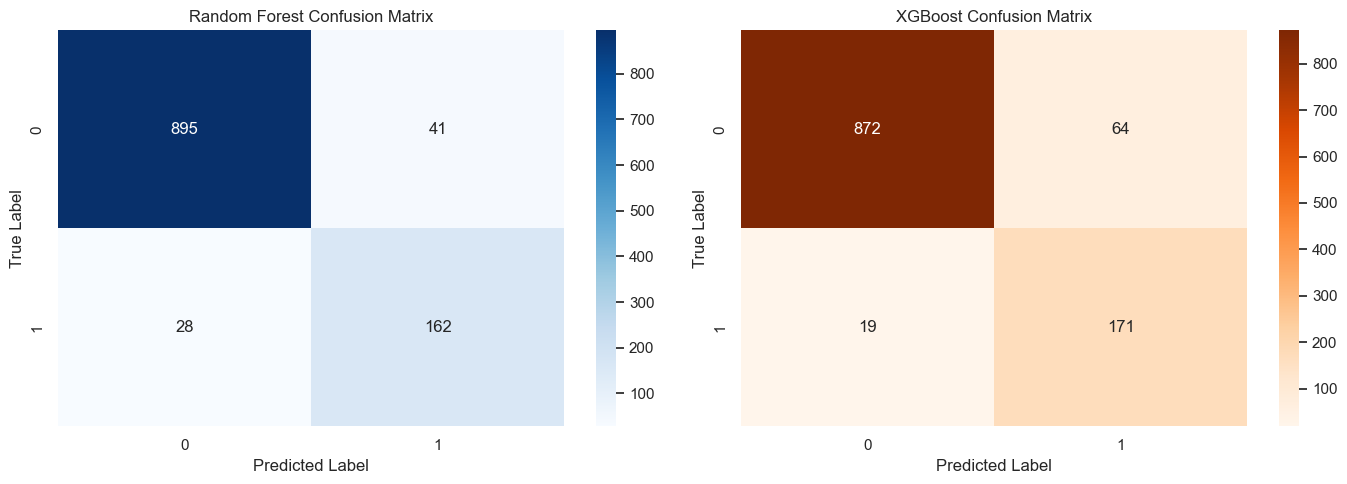

In [17]:
# ==============================================================================
# STEP 7: GRID SEARCH MODEL TRAINING & RECALL-DRIVEN EVALUATION VISUALS
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Running Grid Search parameter tuning across Random Forest
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf_base, rf_param_grid, scoring='recall', cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# 2. Implementing Grid Search parameter optimization for XGBoost
xgb_base = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42, eval_metric='logloss')
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 9],
    'learning_rate': [0.05, 0.1]
}
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, scoring='recall', cv=3, n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb_model = xgb_grid.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

# ==========================================
# EVALUATION REPORT PRINTING & VISUALIZATION
# ==========================================

print("======================================================")
print("===       RANDOM FOREST CLASSIFICATION REPORT      ===")
print("======================================================")
print(f"Optimized Hyperparameters: {rf_grid.best_params_}")
print(classification_report(y_test, y_pred_rf))

print("\n======================================================")
print("===          XGBOOST CLASSIFICATION REPORT         ===")
print("======================================================")
print(f"Optimized Hyperparameters: {xgb_grid.best_params_}")
print(classification_report(y_test, y_pred_xgb))

# Plotting Confusion Matrices side-by-side untuk visualisasi profesional
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [18]:
import joblib
# Simpan model dan scaler terbaik setelah training di notebook kamu
joblib.dump(best_xgb_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'robust_scaler.pkl')

['robust_scaler.pkl']